In [2]:
# Diagnostic: ensure pandas, matplotlib, numpy, and seaborn are available
import sys, subprocess
print('Kernel Python executable:', sys.executable)
print('Python version:', sys.version)
packages = ['pandas', 'matplotlib', 'numpy', 'seaborn']
for pkg in packages:
    try:
        __import__(pkg)
        print(f'{pkg} is available')
    except Exception:
        print(f'{pkg} not found — attempting install...')
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
            import importlib; importlib.invalidate_caches()
            __import__(pkg)
            print(f'{pkg} installed successfully')
        except Exception as e_install:
            print(f'Failed to install {pkg}:', repr(e_install))
            print('If installation fails, run in terminal: pip install', pkg)

Kernel Python executable: c:\Program Files\Python311\python.exe
Python version: 3.11.4 (tags/v3.11.4:d2340ef, Jun  7 2023, 05:45:37) [MSC v.1934 64 bit (AMD64)]
pandas is available
matplotlib is available
numpy is available
seaborn not found — attempting install...
seaborn installed successfully


In [4]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np  
import seaborn as sns

In [5]:
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [6]:
df = pd.read_csv('AIML Dataset.csv')

In [7]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [10]:
round((df["isFraud"].value_counts()[1]/df.shape[0])*100,2)

np.float64(0.13)

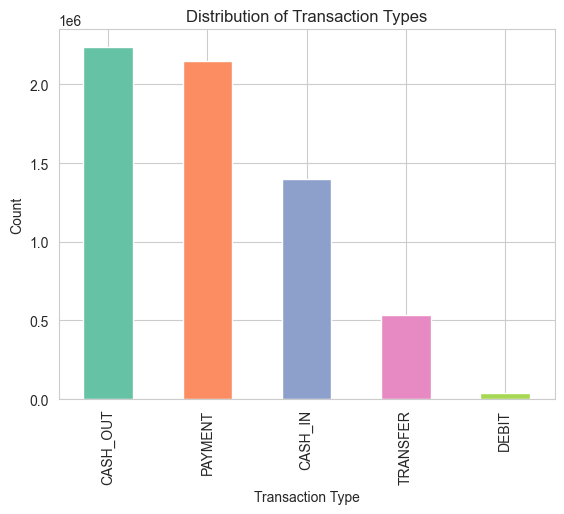

In [12]:
df["type"].value_counts().plot(kind="bar",title="Distribution of Transaction Types", xlabel="Transaction Type", ylabel="Count",color=sns.color_palette("Set2"))
plt.show()

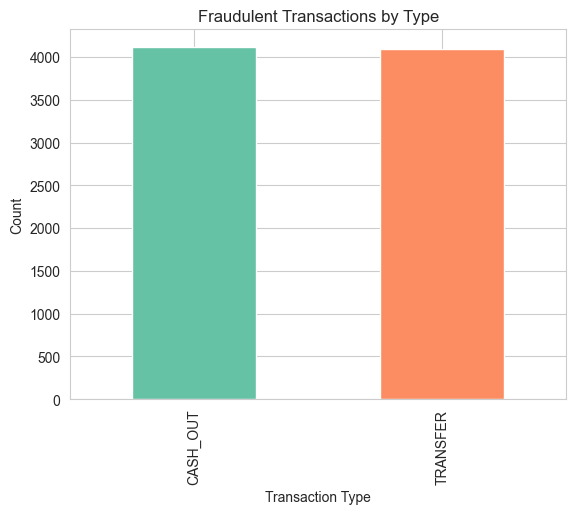

In [16]:
fraud_by_type = df[df["isFraud"]==1]["type"].value_counts()
fraud_by_type.plot(kind="bar", title="Fraudulent Transactions by Type", xlabel="Transaction Type", ylabel="Count", color=sns.color_palette("Set2"))
plt.show()

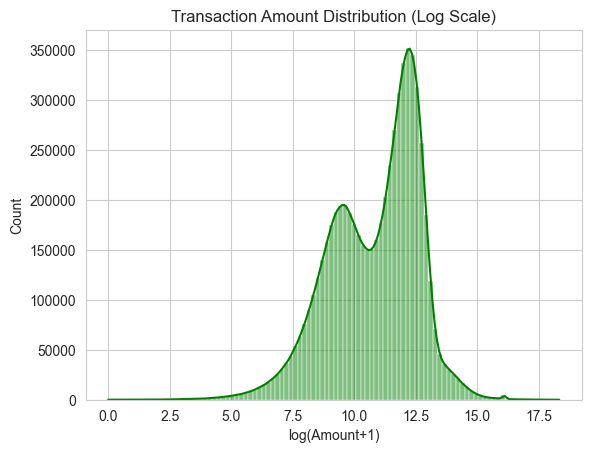

In [20]:
sns.histplot(np.log1p(df["amount"]),bins=100,kde=True,color="green")
plt.title("Transaction Amount Distribution (Log Scale)")
plt.xlabel("log(Amount+1)")
plt.show()

In [21]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"]=df["newbalanceDest"]-df["oldbalanceDest"]

In [22]:
(df["balanceDiffOrig"]<0).sum()

np.int64(1399253)

In [23]:
(df["balanceDiffDest"]<0).sum()

np.int64(1238864)

In [25]:
fraud_types=df[df['type'].isin(["TRANSFER","CASH_OUT"])]

In [26]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

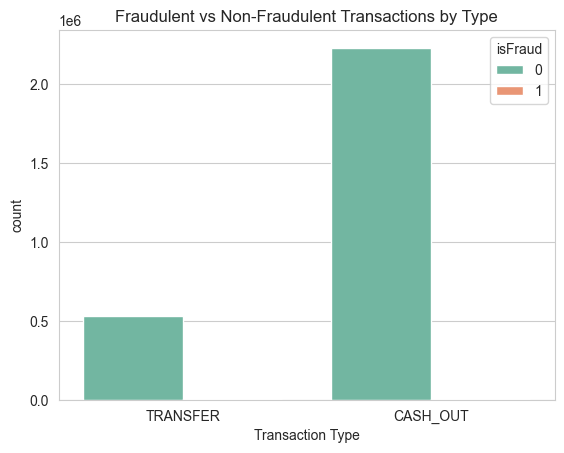

In [27]:
sns.countplot(data=fraud_types, x="type", hue="isFraud", palette="Set2")
plt.title("Fraudulent vs Non-Fraudulent Transactions by Type")
plt.xlabel("Transaction Type")
plt.show()

In [33]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0)
    & (df["newbalanceOrig"] == 0)
    & (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]

In [34]:
len(zero_after_transfer)

1188074

In [35]:
zero_after_transfer.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Ensure scikit-learn is available and print its version
import sys, subprocess
try:
    import sklearn
    print('scikit-learn available, version:', sklearn.__version__)
except Exception:
    print('scikit-learn not found — attempting to install scikit-learn...')
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-learn'])
        import importlib; importlib.invalidate_caches()
        import sklearn
        print('scikit-learn installed, version:', sklearn.__version__)
    except Exception as e:
        print('Failed to install scikit-learn:', repr(e))
        print('Run in terminal: pip install scikit-learn')